In [1]:
from read_model_runs import read_model_runs

# Ler dados completos
question_long_df = \
    read_model_runs('../../data/processed/model-runs')


In [2]:
from read_model_runs import filter_complete_questions

models = ['gpt-4o-mini', 'gemma-3-27b-it', 'gemma-3-12b-it', 'gemma-3-4b-it', 'gemma-3n-e4b-it']
models = ['gemma-3-27b-it', 'gemma-3-12b-it', 'gemma-3-4b-it'] #'gemma-3n-e4b-it', 'qwen']

firacs = ['FILA_', "FIRAC", 'FIR__', 'FI___', 'FIL__', '_____', ]
firacs = ['FILA_', 'FIL__', 'FIR__', 'F____', 'FI___', '_____', 'FIRAC', 'unstructured']
question_long_df, question_wide_df, model_order, firac_order, completeness_map_df = filter_complete_questions(question_long_df, models, firacs)

print('completeness map', completeness_map_df.sort_values(by='completeness_pct'))

print('shape:', question_long_df.shape)
print('# unique questions:', question_long_df['question_id'].nunique())
print("model order:", model_order)
print("firac order:", firac_order)

#question_long_df[question_long_df.model_name == 'Qwen/Qwen2.5-7B-Instruct'][question_long_df.firac == 'unstructured']

completeness map         model_name         firac  n_questions  completeness_pct
22   gemma-3-4b-it         FIRAC         3051          0.944582
19   gemma-3-4b-it         F____         3069          0.950155
11  gemma-3-12b-it         F____         3077          0.952632
3   gemma-3-27b-it         F____         3102          0.960372
14  gemma-3-12b-it         FIRAC         3138          0.971517
10  gemma-3-12b-it         FIR__         3168          0.980805
18   gemma-3-4b-it         FIR__         3178          0.983901
16   gemma-3-4b-it         FILA_         3182          0.985139
6   gemma-3-27b-it         FIRAC         3196          0.989474
21   gemma-3-4b-it         _____         3198          0.990093
13  gemma-3-12b-it         _____         3200          0.990712
5   gemma-3-27b-it         _____         3201          0.991022
20   gemma-3-4b-it         FI___         3201          0.991022
17   gemma-3-4b-it         FIL__         3207          0.992879
12  gemma-3-12b-it     

In [4]:
question_wide_df.head()

,question_id,materia,model_name,F____,_____,unstructured,FIL__,FI___,FIR__,FILA_,FIRAC
0,oab-1.pdf-002,ÉTICA PROFISSIONAL,gemma-3-12b-it,True,False,True,True,True,True,True,True
1,oab-1.pdf-002,ÉTICA PROFISSIONAL,gemma-3-27b-it,False,False,True,True,True,True,True,True
2,oab-1.pdf-002,ÉTICA PROFISSIONAL,gemma-3-4b-it,True,True,True,True,True,True,True,True
3,oab-1.pdf-004,ÉTICA PROFISSIONAL,gemma-3-12b-it,False,False,True,True,True,True,True,True
4,oab-1.pdf-004,ÉTICA PROFISSIONAL,gemma-3-27b-it,True,True,True,True,True,True,True,True


In [5]:
question_wide_df.columns

Index(['question_id', 'materia', 'model_name', 'F____', '_____',
       'unstructured', 'FIL__', 'FI___', 'FIR__', 'FILA_', 'FIRAC'],
      dtype='object')

In [6]:
import pandas as pd

# -------------------------------
# 1. Definir colunas FIRAC
# -------------------------------
firac_cols = firac_order

# -------------------------------
# 2. Converter booleanos → int
#    (PCA não gosta de True/False)
# -------------------------------
question_wide_df[firac_cols] = (
    question_wide_df[firac_cols]
    .astype(int)
)

# -------------------------------
# 3. Long → Wide:
#    (question_id, model_name) × FIRAC
# -------------------------------
df_long = question_wide_df.melt(
    id_vars=["question_id", "model_name"],
    value_vars=firac_cols,
    var_name="firac",
    value_name="value"
)

# -------------------------------
# 4. Criar nome da coluna combinada
#    model_name + FIRAC
# -------------------------------
df_long["feature"] = (
    df_long["model_name"] + "|" + df_long["firac"]
)

# -------------------------------
# 5. Pivot final:
#    1 linha por question_id
# -------------------------------
pca_input_df = (
    df_long
    .pivot_table(
        index="question_id",
        columns="feature",
        values="value",
        aggfunc="mean"   # robusto caso haja duplicatas
    )
    .fillna(0)
)

# -------------------------------
# 6. (Opcional) Ordenar colunas
# -------------------------------
pca_accuracy_input_df = pca_input_df.sort_index(axis=1)

# -------------------------------
# 7. Pronto para PCA
# -------------------------------
print(pca_accuracy_input_df.shape)
pca_accuracy_input_df.head()


(3001, 24)


feature,gemma-3-12b-it|FILA_,gemma-3-12b-it|FIL__,gemma-3-12b-it|FIRAC,gemma-3-12b-it|FIR__,gemma-3-12b-it|FI___,gemma-3-12b-it|F____,gemma-3-12b-it|_____,gemma-3-12b-it|unstructured,gemma-3-27b-it|FILA_,gemma-3-27b-it|FIL__,...,gemma-3-27b-it|_____,gemma-3-27b-it|unstructured,gemma-3-4b-it|FILA_,gemma-3-4b-it|FIL__,gemma-3-4b-it|FIRAC,gemma-3-4b-it|FIR__,gemma-3-4b-it|FI___,gemma-3-4b-it|F____,gemma-3-4b-it|_____,gemma-3-4b-it|unstructured
question_id,,,,,,,,,,,,,,,,,,,,,
oab-1.pdf-002,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
oab-1.pdf-004,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
oab-1.pdf-006,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
oab-1.pdf-008,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0
oab-1.pdf-009,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0


In [7]:
import pandas as pd

pca_entailment_input_df = pd.read_csv(
    "../../data/processed/question_entailment_wide.csv",
    index_col="question_id"
)

pca_entailment_input_df


,FILA_|application,FILA_|conclusion,FILA_|rule,FIR__|application,FIR__|conclusion,FIR__|rule,FI___|application,FI___|conclusion,FI___|rule,_____|application,_____|conclusion,_____|rule
question_id,,,,,,,,,,,,
oab-1.pdf-002,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0
oab-1.pdf-003,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,-1.0,-1.0,0.0
oab-1.pdf-004,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
oab-1.pdf-005,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0
oab-1.pdf-006,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
oab-96.pdf-079,1.0,0.0,1.0,1.0,1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0
oab-97.pdf-008,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
oab-97.pdf-012,1.0,0.0,1.0,1.0,0.0,1.0,-1.0,0.0,0.0,-1.0,-1.0,0.0


In [8]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


def run_pca(pca_input_df):
    """
    Executa PCA sobre um dataframe no formato:
    - linhas: observações (e.g., question_id)
    - colunas: features numéricas

    Retorna:
    - pca_scores_df: scores do PCA por observação
    - loadings_df: loadings das features
    - explained_variance_df: variância explicada por componente
    - pca_model: objeto PCA treinado
    - scaler: objeto StandardScaler treinado
    """

    # ---------------------------------------
    # 1. Matriz X (observações × features)
    # ---------------------------------------
    X = pca_input_df.values
    index = pca_input_df.index
    feature_names = pca_input_df.columns

    # ---------------------------------------
    # 2. Padronização (Z-score)
    # ---------------------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ---------------------------------------
    # 3. PCA (sem fixar n_components)
    # ---------------------------------------
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)

    # ---------------------------------------
    # 4. Scores do PCA
    # ---------------------------------------
    pca_scores_df = pd.DataFrame(
        X_pca,
        index=index,
        columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
    )

    # ---------------------------------------
    # 5. Loadings
    # ---------------------------------------
    loadings_df = pd.DataFrame(
        pca.components_.T,
        index=feature_names,
        columns=pca_scores_df.columns
    )

    # ---------------------------------------
    # 6. Variância explicada
    # ---------------------------------------
    explained_variance_df = pd.DataFrame({
        "PC": pca_scores_df.columns,
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "explained_variance_cumulative": np.cumsum(pca.explained_variance_ratio_)
    })

    return (
        pca_scores_df,
        feature_names,
        loadings_df,
        explained_variance_df,
        pca
    )


pca_accuracy_scores_df, feature_names_accuracy, loadings_accuracy_df, explained_variance_df, pca_accuracy = run_pca(pca_accuracy_input_df)
pca_entailment_scores_df, feature_names_entailment, loadings_entailment_df, explained_varince_df, pca_entailment = run_pca(pca_entailment_input_df)

In [9]:
import pandas as pd
import numpy as np
from IPython.display import display


def explain_variance(pca):
    """
    Gera um DataFrame com a variância explicada do PCA.
    """

    explained_variance_df = pd.DataFrame({
        "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
    })

    return explained_variance_df


# --------------------------------------------------
# Mostrar as duas tabelas explicitamente
# --------------------------------------------------
print("PCA-Accuracy:")
display(explain_variance(pca_accuracy))

print("PCA-Entailment")
display(explain_variance(pca_entailment))


PCA-Accuracy:


,PC,explained_variance_ratio,cumulative_variance
0,PC1,0.308112,0.308112
1,PC2,0.096176,0.404288
2,PC3,0.078235,0.482523
3,PC4,0.049449,0.531972
4,PC5,0.047575,0.579547
5,PC6,0.039851,0.619398
6,PC7,0.036532,0.655930
7,PC8,0.031984,0.687914
8,PC9,0.029033,0.716947
9,PC10,0.027579,0.744526


PCA-Entailment


,PC,explained_variance_ratio,cumulative_variance
0,PC1,3.260771e-01,0.326077
1,PC2,1.557016e-01,0.481779
2,PC3,1.108830e-01,0.592662
3,PC4,1.084223e-01,0.701084
4,PC5,7.759320e-02,0.778677
5,PC6,7.257047e-02,0.851248
6,PC7,5.819686e-02,0.909445
7,PC8,5.337353e-02,0.962818
8,PC9,3.718197e-02,1.000000
9,PC10,1.236389e-17,1.000000


In [10]:
import pandas as pd
from IPython.display import display


def show_loadings(pca, feature_names):
    """
    Gera a tabela de loadings do PCA e organiza por FIRAC e model_name.

    Parâmetros
    ----------
    pca : sklearn.decomposition.PCA
        Objeto PCA já ajustado (fit)
    feature_names : list-like
        Nomes das features no formato "model_name|firac"

    Retorna
    -------
    loadings_df : pd.DataFrame
        DataFrame indexado por (firac, model_name)
        com colunas PC1, PC2, ...
    """

    # ---------------------------------------
    # 1. Loadings
    # ---------------------------------------
    loadings_df = pd.DataFrame(
        pca.components_.T,
        index=feature_names,
        columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])]
    )

    # ---------------------------------------
    # 2. Quebrar feature → model_name + firac
    # ---------------------------------------
    loadings_df = (
        loadings_df
        .reset_index()
        .rename(columns={"index": "feature"})
    )

    loadings_df[["model_name", "firac"]] = (
        loadings_df["feature"]
        .str.split("|", expand=True)
    )

    loadings_df = loadings_df.drop(columns="feature")

    # ---------------------------------------
    # 3. Reordenar colunas
    # ---------------------------------------
    pc_cols = [c for c in loadings_df.columns if c.startswith("PC")]

    loadings_df = (
        loadings_df[
            ["firac", "model_name"] + pc_cols
        ]
        .sort_values(by="firac")
        .set_index(["firac", "model_name"])
    )

    return loadings_df


# --------------------------------------------------
# Mostrar as duas tabelas (sem notação científica)
# --------------------------------------------------
print("Loadings — Accuracy PCA")
display(
    show_loadings(pca_accuracy, feature_names_accuracy)
    .style
    .format("{:.3f}")
)

print("Loadings — Entailment PCA")
display(
    show_loadings(pca_entailment, feature_names_entailment)
    .style
    .format("{:.3f}")
)


Loadings — Accuracy PCA


Loadings — Entailment PCA


In [11]:
import pandas as pd
import numpy as np

loadings_df = loadings_accuracy_df

# --------------------------------------------------
# 0) Renomear nível do MultiIndex: model_name -> model
# --------------------------------------------------
if isinstance(loadings_df.index, pd.MultiIndex):
    loadings_df = loadings_df.rename_axis(
        index={"model_name": "model"}
    )


def escape_latex(text):
    if not isinstance(text, str):
        return text
    return (
        text
        .replace("\\", "\\textbackslash{}")
        .replace("_", "\\_")
        .replace("%", "\\%")
        .replace("&", "\\&")
        .replace("#", "\\#")
        .replace("{", "\\{")
        .replace("}", "\\}")
    )


# --------------------------------------------------
# 1) Selecionar PC1, PC2 e PC3
# --------------------------------------------------
latex_df = loadings_df[["PC1", "PC2", "PC3"]].copy()
latex_df = latex_df.round(2)


# --------------------------------------------------
# 2) Escape LaTeX nos nomes das features (index)
# --------------------------------------------------
latex_df.index = latex_df.index.map(escape_latex)


# --------------------------------------------------
# 3) Função de coloração ACL-style
# --------------------------------------------------
def color_cell(val, eps=0.05):
    if pd.isna(val):
        return ""

    if abs(val) < eps:
        return f"{val:.2f}"

    intensity = int(min(abs(val) * 100, 70))

    if val > 0:
        return f"\\cellcolor{{green!{intensity}}}{val:.2f}"
    else:
        return f"\\cellcolor{{red!{intensity}}}{val:.2f}"


# --------------------------------------------------
# 4) Aplicar coloração
# --------------------------------------------------
styled_df = latex_df.copy()
for col in styled_df.columns:
    styled_df[col] = styled_df[col].apply(color_cell)


# --------------------------------------------------
# 5) Gerar LaTeX
# --------------------------------------------------
latex_table = styled_df.to_latex(
    escape=False,   # NÃO mudar isso
    column_format="lccc",
    bold_rows=False,
    caption=(
        "PCA loadings for the first three principal components. "
        "Green indicates positive contributions, red negative contributions, "
        "and near-zero values are shown in white."
    ),
    label="tab:pca_loadings_pc1_pc3"
)

print(latex_table)


\begin{table}
\caption{PCA loadings for the first three principal components. Green indicates positive contributions, red negative contributions, and near-zero values are shown in white.}
\label{tab:pca_loadings_pc1_pc3}
\begin{tabular}{lccc}
\toprule
 & PC1 & PC2 & PC3 \\
feature &  &  &  \\
\midrule
gemma-3-12b-it|FILA\_ & \cellcolor{green!10}0.10 & \cellcolor{green!40}0.40 & \cellcolor{green!5}0.05 \\
gemma-3-12b-it|FIL\_\_ & \cellcolor{green!25}0.25 & -0.00 & \cellcolor{red!16}-0.16 \\
gemma-3-12b-it|FIRAC & \cellcolor{green!9}0.09 & \cellcolor{green!43}0.43 & 0.02 \\
gemma-3-12b-it|FIR\_\_ & \cellcolor{green!17}0.17 & \cellcolor{green!23}0.23 & -0.03 \\
gemma-3-12b-it|FI\_\_\_ & \cellcolor{green!26}0.26 & -0.04 & \cellcolor{red!16}-0.16 \\
gemma-3-12b-it|F\_\_\_\_ & \cellcolor{green!24}0.24 & \cellcolor{red!5}-0.05 & \cellcolor{red!14}-0.14 \\
gemma-3-12b-it|\_\_\_\_\_ & \cellcolor{green!25}0.25 & \cellcolor{red!9}-0.09 & \cellcolor{red!16}-0.16 \\
gemma-3-12b-it|unstructured & \c

In [12]:
import pandas as pd


def enrich_pca(pca_scores_df, question_long_df, output_path=None):
    """
    Enriquece o DataFrame de scores do PCA com metadados da questão.

    Parâmetros
    ----------
    pca_scores_df : pd.DataFrame
        DataFrame com os scores do PCA (index ou coluna question_id)
    question_long_df : pd.DataFrame
        DataFrame original contendo metadados das questões
    output_path : str ou None (opcional)
        Caminho para salvar o CSV resultante. Se None, não salva.

    Retorna
    -------
    enriched_pca_df : pd.DataFrame
        DataFrame de PCA enriquecido com:
        - materia
        - tema
        - oab_test_id
    """

    # --------------------------------------------------
    # 1) Extrair metadados únicos por question_id
    # --------------------------------------------------
    question_meta_df = (
        question_long_df[
            ["question_id", "materia", "law_subfield", "tema", "oab_test_id"]
        ]
        .drop_duplicates(subset=["question_id"])
    )

    # --------------------------------------------------
    # 2) Garantir question_id como coluna (se estiver no índice)
    # --------------------------------------------------
    if "question_id" not in pca_scores_df.columns:
        pca_scores_df = pca_scores_df.reset_index()

    # --------------------------------------------------
    # 3) Merge com metadados
    # --------------------------------------------------
    enriched_pca_df = (
        pca_scores_df
        .merge(
            question_meta_df,
            on="question_id",
            how="left"
        )
    )

    # --------------------------------------------------
    # 4) Reordenar colunas (metadados primeiro)
    # --------------------------------------------------
    meta_cols = ["materia", "law_subfield", "tema", "oab_test_id"]
    other_cols = [c for c in enriched_pca_df.columns if c not in meta_cols]

    enriched_pca_df = enriched_pca_df[meta_cols + other_cols]

    # --------------------------------------------------
    # 5) Salvar (opcional)
    # --------------------------------------------------
    if output_path is not None:
        enriched_pca_df.to_csv(output_path, index=False)

    return enriched_pca_df


pca_accuracy_scores_df = enrich_pca(pca_accuracy_scores_df, question_long_df)
pca_entailment_scores_df = enrich_pca(pca_entailment_scores_df, question_long_df)

In [13]:
import pandas as pd
import numpy as np

# --------------------------------------------------
# 0) Renomear coluna model_name -> model (se existir)
# --------------------------------------------------
if "model_name" in loadings_df.columns:
    loadings_df = loadings_df.rename(columns={"model_name": "model"})


def escape_latex(text):
    if not isinstance(text, str):
        return text
    return (
        text
        .replace("\\", "\\textbackslash{}")
        .replace("_", "\\_")
        .replace("%", "\\%")
        .replace("&", "\\&")
        .replace("#", "\\#")
        .replace("{", "\\{")
        .replace("}", "\\}")
    )


# --------------------------------------------------
# 1) Selecionar PC1, PC2 e PC3
# --------------------------------------------------
latex_df = loadings_df[["PC1", "PC2", "PC3"]].copy()
latex_df = latex_df.round(2)


# --------------------------------------------------
# 2) Escape LaTeX nos nomes das features (index)
# --------------------------------------------------
latex_df.index = latex_df.index.map(escape_latex)


# --------------------------------------------------
# 3) Função de coloração ACL-style
# --------------------------------------------------
def color_cell(val, eps=0.05):
    if pd.isna(val):
        return ""

    if abs(val) < eps:
        return f"{val:.2f}"

    intensity = int(min(abs(val) * 100, 70))

    if val > 0:
        return f"\\cellcolor{{green!{intensity}}}{val:.2f}"
    else:
        return f"\\cellcolor{{red!{intensity}}}{val:.2f}"


# --------------------------------------------------
# 4) Aplicar coloração
# --------------------------------------------------
styled_df = latex_df.copy()
for col in styled_df.columns:
    styled_df[col] = styled_df[col].apply(color_cell)


# --------------------------------------------------
# 5) Gerar LaTeX
# --------------------------------------------------
latex_table = styled_df.to_latex(
    escape=False,   # NÃO mudar isso
    column_format="lccc",
    bold_rows=False,
    caption=(
        "PCA loadings for the first three principal components. "
        "Green indicates positive contributions, red negative contributions, "
        "and near-zero values are shown in white."
    ),
    label="tab:pca_loadings_pc1_pc3"
)

print(latex_table)


\begin{table}
\caption{PCA loadings for the first three principal components. Green indicates positive contributions, red negative contributions, and near-zero values are shown in white.}
\label{tab:pca_loadings_pc1_pc3}
\begin{tabular}{lccc}
\toprule
 & PC1 & PC2 & PC3 \\
feature &  &  &  \\
\midrule
gemma-3-12b-it|FILA\_ & \cellcolor{green!10}0.10 & \cellcolor{green!40}0.40 & \cellcolor{green!5}0.05 \\
gemma-3-12b-it|FIL\_\_ & \cellcolor{green!25}0.25 & -0.00 & \cellcolor{red!16}-0.16 \\
gemma-3-12b-it|FIRAC & \cellcolor{green!9}0.09 & \cellcolor{green!43}0.43 & 0.02 \\
gemma-3-12b-it|FIR\_\_ & \cellcolor{green!17}0.17 & \cellcolor{green!23}0.23 & -0.03 \\
gemma-3-12b-it|FI\_\_\_ & \cellcolor{green!26}0.26 & -0.04 & \cellcolor{red!16}-0.16 \\
gemma-3-12b-it|F\_\_\_\_ & \cellcolor{green!24}0.24 & \cellcolor{red!5}-0.05 & \cellcolor{red!14}-0.14 \\
gemma-3-12b-it|\_\_\_\_\_ & \cellcolor{green!25}0.25 & \cellcolor{red!9}-0.09 & \cellcolor{red!16}-0.16 \\
gemma-3-12b-it|unstructured & \c

In [14]:
pip install adjustText


Note: you may need to restart the kernel to use updated packages.


PCA - accuracy:


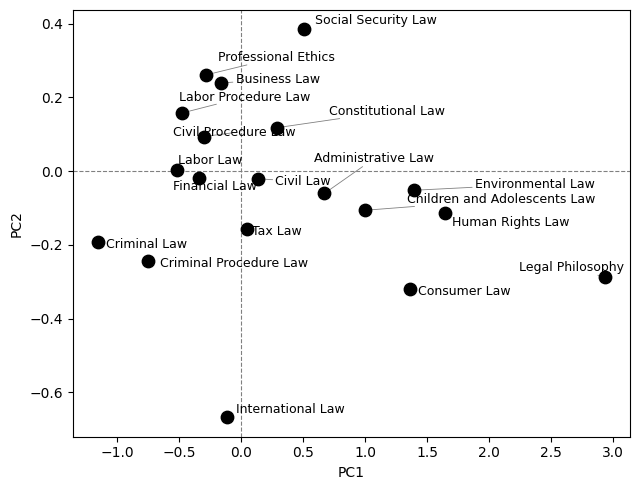

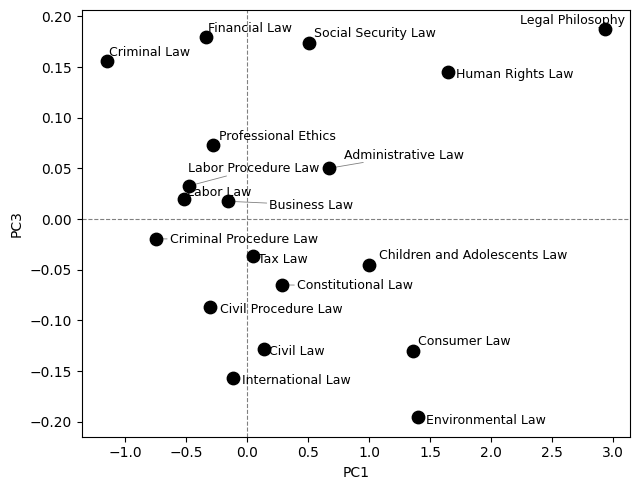

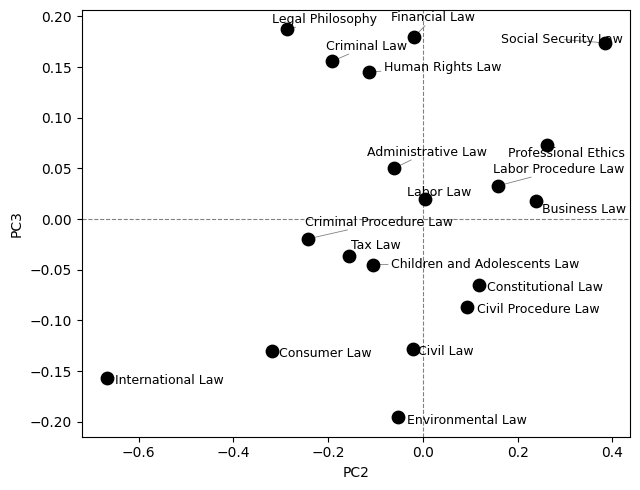

PCA - entailment:


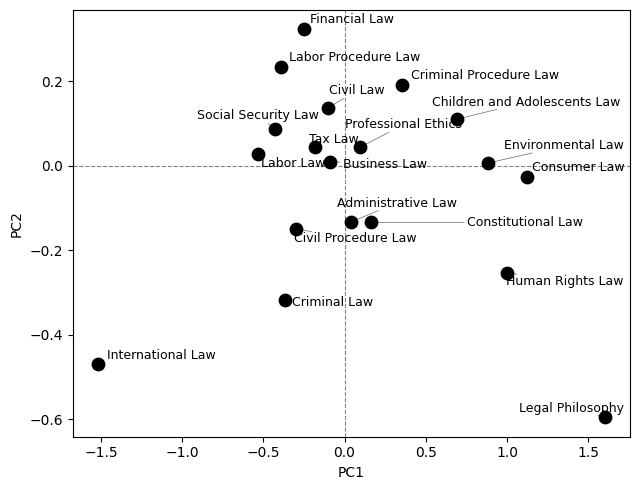

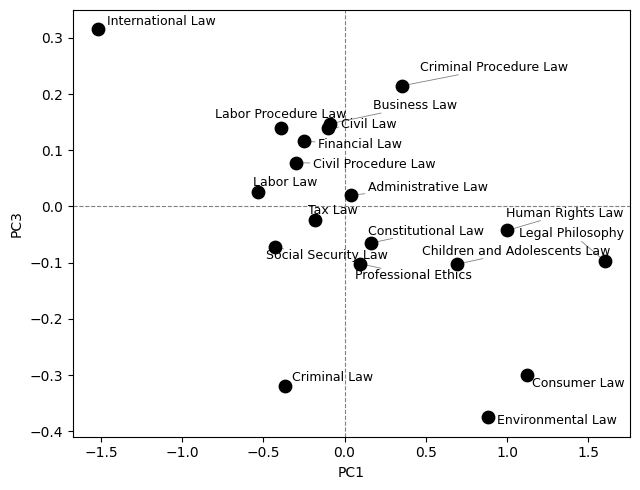

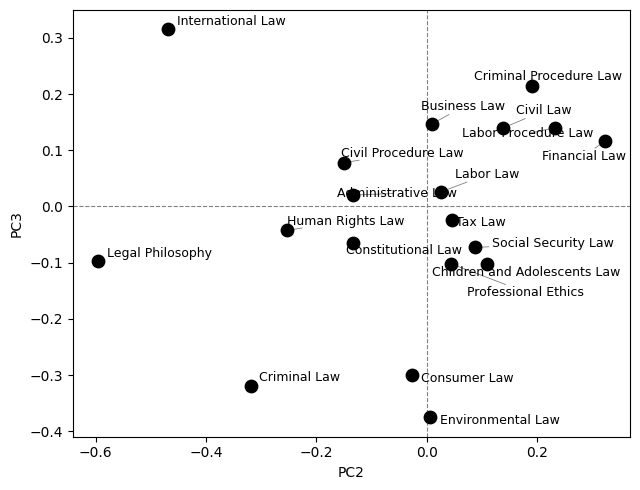

In [15]:
import matplotlib.pyplot as plt
from adjustText import adjust_text
from itertools import combinations


def plot_pca(pca_scores_df, name):
    """
    Gera plots ACL-style dos centróides por matéria
    para todos os pares de PCs (PC1×PC2, PC1×PC3, PC2×PC3).

    Parâmetros
    ----------
    pca_scores_df : pd.DataFrame
        DataFrame contendo colunas:
        - PC1, PC2, PC3, ...
        - materia
    """

    # --------------------------------------------------
    # 0. Filtra matéria a ser removida
    # --------------------------------------------------
    filtered_df = pca_scores_df[
        pca_scores_df["materia"] != "DIREITO ELEITORAL"
    ]

    # --------------------------------------------------
    # 1. Define pares de PCs
    # --------------------------------------------------
    pc_pairs = list(combinations(["PC1", "PC2", "PC3"], 2))

    # --------------------------------------------------
    # 2. Loop sobre os pares de PCs
    # --------------------------------------------------
    for pc_x, pc_y in pc_pairs:

        # ----------------------------------------------
        # 2.1 Calcula centróides por matéria
        # ----------------------------------------------
        centroids_df = (
            filtered_df
            .groupby("law_subfield")[[pc_x, pc_y]]
            .mean()
            .reset_index()
        )

        # ----------------------------------------------
        # 2.2 Plot ACL-style
        # ----------------------------------------------
        plt.figure(figsize=(6.5, 5))

        plt.scatter(
            centroids_df[pc_x],
            centroids_df[pc_y],
            s=80,
            color="black",
            zorder=3
        )

        # Labels com repulsão
        texts = []
        for _, row in centroids_df.iterrows():
            texts.append(
                plt.text(
                    row[pc_x],
                    row[pc_y],
                    row["law_subfield"],
                    fontsize=9
                )
            )

        adjust_text(
            texts,
            arrowprops=dict(
                arrowstyle="-",
                color="gray",
                lw=0.6
            )
        )

        # Linhas de referência
        plt.axhline(0, color="gray", linewidth=0.8, linestyle="--", zorder=1)
        plt.axvline(0, color="gray", linewidth=0.8, linestyle="--", zorder=1)

        # Labels e título
        plt.xlabel(pc_x)
        plt.ylabel(pc_y)
       # plt.title(f"Centroids of Legal Subjects in the {pc_x}–{pc_y} Space")

        # ----------------------------------------------
        # 2.3 Salva em PDF e mostra na tela
        # ----------------------------------------------
        plt.tight_layout()
        plt.savefig(
            f"../../reports/pca_centroids_{name}_{pc_x.lower()}_{pc_y.lower()}_materia.pdf",
            format="pdf",
            bbox_inches="tight"
        )
        plt.show()


print("PCA - accuracy:")
plot_pca(pca_accuracy_scores_df, name="accuracy")

print("PCA - entailment:")
plot_pca(pca_entailment_scores_df, name="entailment")

PCA Biplot FIRAC – Accuracy


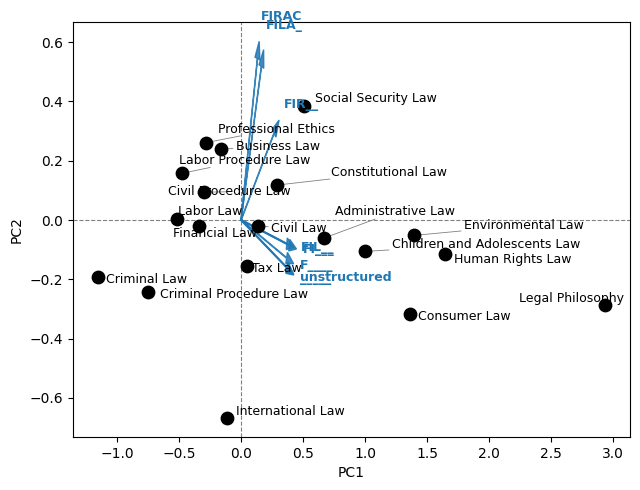

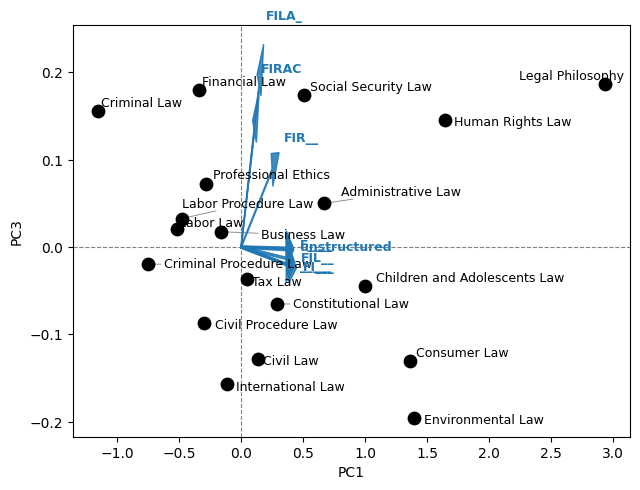

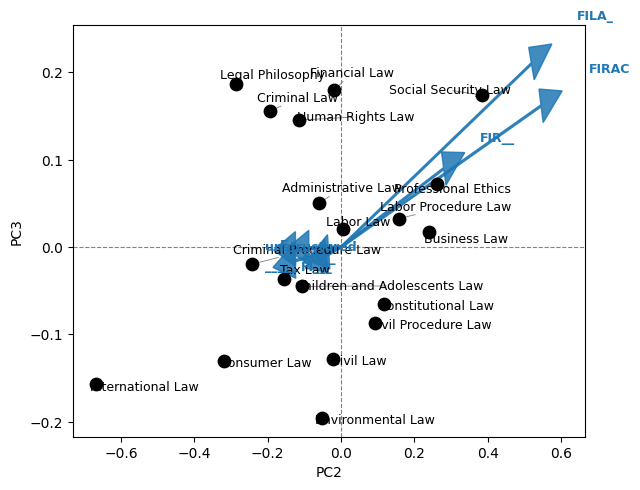

PCA Biplot FIRAC – Entailment


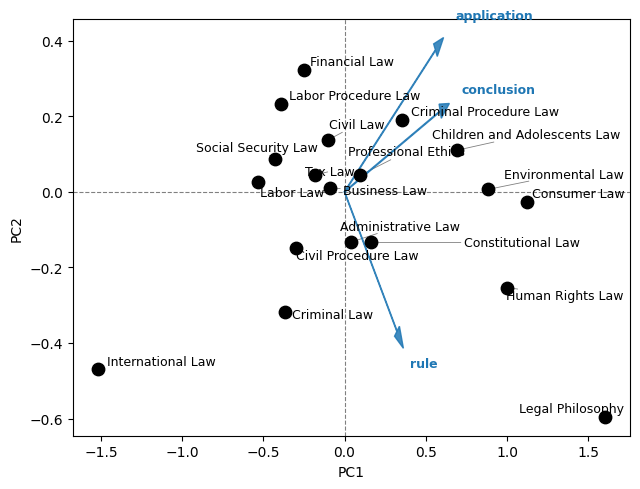

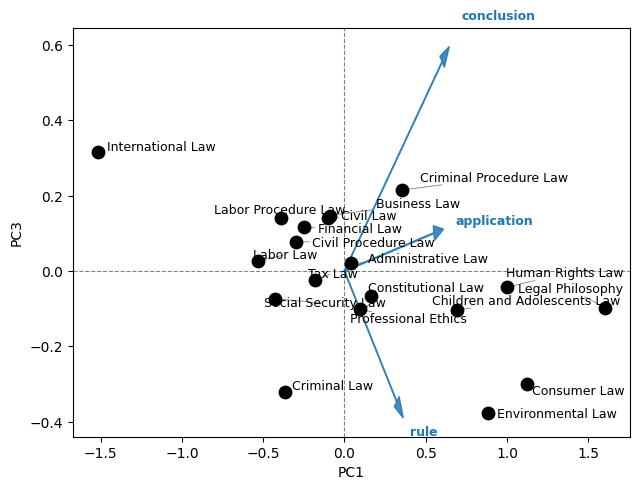

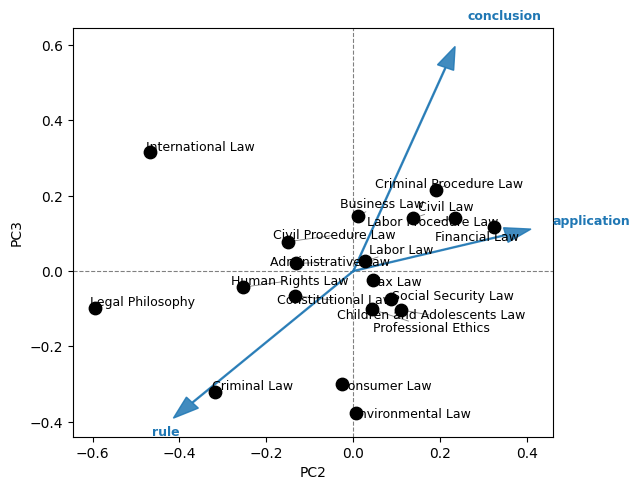

In [16]:
import matplotlib.pyplot as plt
from adjustText import adjust_text
from itertools import combinations
import pandas as pd


def plot_pca_biplot_firac(
    pca_scores_df,
    loadings_df,
    name,
    loading_scale=0.1
):
    """
    PCA Biplot ACL-style com agregação por FIRAC.

    - Pontos: centróides por subárea do direito
    - Vetores: soma vetorial dos loadings por estágio FIRAC
    - Escala dos vetores controlada exclusivamente por loading_scale
    """

    # --------------------------------------------------
    # 0. Filtra subárea
    # --------------------------------------------------
    filtered_df = pca_scores_df[
        pca_scores_df["materia"] != "DIREITO ELEITORAL"
    ]

    # --------------------------------------------------
    # 1. Extrai FIRAC do índice (modelo|firac → firac)
    # --------------------------------------------------
    loadings_firac = loadings_df.copy()
    loadings_firac["firac"] = (
        loadings_firac.index
        .str.split("|")
        .str[-1]
    )

    # --------------------------------------------------
    # 2. Soma vetorial por FIRAC
    # --------------------------------------------------
    firac_loadings = (
        loadings_firac
        .groupby("firac")
        .sum(numeric_only=True)
    )

    # --------------------------------------------------
    # 3. Pares de PCs
    # --------------------------------------------------
    pc_pairs = list(combinations(["PC1", "PC2", "PC3"], 2))

    # --------------------------------------------------
    # 4. Loop
    # --------------------------------------------------
    for pc_x, pc_y in pc_pairs:

        # ----------------------------------------------
        # 4.1 Centrôides
        # ----------------------------------------------
        centroids_df = (
            filtered_df
            .groupby("law_subfield")[[pc_x, pc_y]]
            .mean()
            .reset_index()
        )

        # ----------------------------------------------
        # 4.2 Figura
        # ----------------------------------------------
        plt.figure(figsize=(6.5, 5))

        plt.scatter(
            centroids_df[pc_x],
            centroids_df[pc_y],
            s=80,
            color="black",
            zorder=3
        )

        # Labels dos centróides
        texts = []
        for _, row in centroids_df.iterrows():
            texts.append(
                plt.text(
                    row[pc_x],
                    row[pc_y],
                    row["law_subfield"],
                    fontsize=9
                )
            )

        adjust_text(
            texts,
            arrowprops=dict(
                arrowstyle="-",
                color="gray",
                lw=0.6
            )
        )

        # ----------------------------------------------
        # 4.3 Vetores FIRAC
        # ----------------------------------------------
        for firac, row in firac_loadings.iterrows():

            x_loading = row[pc_x] * loading_scale
            y_loading = row[pc_y] * loading_scale

            plt.arrow(
                0, 0,
                x_loading,
                y_loading,
                color="tab:blue",
                alpha=0.85,
                width=0.0025,
                head_width=0.04,
                length_includes_head=True,
                zorder=2
            )

            plt.text(
                x_loading * 1.12,
                y_loading * 1.12,
                firac,
                fontsize=9,
                fontweight="bold",
                color="tab:blue"
            )

        # ----------------------------------------------
        # 4.4 Eixos
        # ----------------------------------------------
        plt.axhline(0, color="gray", linewidth=0.8, linestyle="--", zorder=1)
        plt.axvline(0, color="gray", linewidth=0.8, linestyle="--", zorder=1)

        plt.xlabel(pc_x)
        plt.ylabel(pc_y)

        # ----------------------------------------------
        # 4.5 Salva
        # ----------------------------------------------
        plt.tight_layout()
        plt.savefig(
            f"../../reports/pca_biplot_firac_{name}_{pc_x.lower()}_{pc_y.lower()}_materia.pdf",
            format="pdf",
            bbox_inches="tight"
        )
        plt.show()


# --------------------------------------------------
# Chamadas
# --------------------------------------------------

print("PCA Biplot FIRAC – Accuracy")
plot_pca_biplot_firac(
    pca_accuracy_scores_df,
    loadings_accuracy_df,
    name="accuracy",
    loading_scale=0.6
)

print("PCA Biplot FIRAC – Entailment")
plot_pca_biplot_firac(
    pca_entailment_scores_df,
    loadings_entailment_df,
    name="entailment",
    loading_scale=0.6
)


In [17]:
import numpy as np
import pandas as pd
from scipy.spatial import procrustes


def procrustes_similarity(pca_df_1, pca_df_2, pcs=["PC1", "PC2"]):
    """
    Computa a similaridade entre dois PCA score DataFrames usando Procrustes,
    considerando apenas a interseção de question_id.
    """

    # -------------------------------
    # 0) Cópia defensiva + remove colunas não geométricas
    # -------------------------------
    drop_cols = ["materia", "law_subfield", "tema", "oab_test_id"]
    df1 = pca_df_1.drop(columns=drop_cols, errors="ignore").copy()
    df2 = pca_df_2.drop(columns=drop_cols, errors="ignore").copy()

    # -------------------------------
    # 1) Interseção por question_id
    # -------------------------------
    if "question_id" not in df1.columns or "question_id" not in df2.columns:
        raise ValueError("Ambos os DataFrames devem conter a coluna 'question_id'.")

    common_qids = set(df1["question_id"]).intersection(df2["question_id"])

    if len(common_qids) < 2:
        raise ValueError("É necessário ao menos 2 question_id em comum.")

    df1 = (
        df1[df1["question_id"].isin(common_qids)]
        .sort_values("question_id")
        .set_index("question_id")
    )

    df2 = (
        df2[df2["question_id"].isin(common_qids)]
        .sort_values("question_id")
        .set_index("question_id")
    )

    # -------------------------------
    # 2) Selecionar PCs
    # -------------------------------
    if pcs is None:
        pcs = sorted(set(df1.columns).intersection(df2.columns))

    if len(pcs) < 2:
        raise ValueError("Procrustes requer ao menos 2 PCs.")

    X = df1[pcs].values
    Y = df2[pcs].values

    # -------------------------------
    # 3) Procrustes
    # -------------------------------
    _, _, disparity = procrustes(X, Y)

    return {
        "n_questions": len(common_qids),
        "pcs_used": pcs,
        "disparity": disparity,
        "similarity": 1 - disparity
    }


print(procrustes_similarity(pca_accuracy_scores_df, pca_accuracy_scores_df, pcs=["PC1", "PC2"]))
print(procrustes_similarity(pca_accuracy_scores_df, pca_entailment_scores_df, pcs=["PC1", "PC2"]))

{'n_questions': 3001, 'pcs_used': ['PC1', 'PC2'], 'disparity': 4.468854253577429e-32, 'similarity': 1.0}
{'n_questions': 1535, 'pcs_used': ['PC1', 'PC2'], 'disparity': 0.77159164513867, 'similarity': 0.22840835486133004}


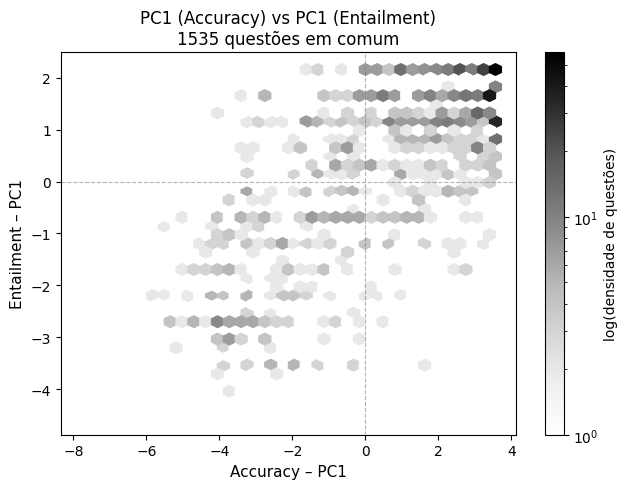

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def plot_scatter_plot_pcs(
    pca_scores_df_1,
    pca_scores_df_2,
    pc_1="PC1",
    pc_2="PC1",
    label_1="PCA-1",
    label_2="PCA-2",
    figsize=(6.5, 5),
    gridsize=35
):
    """
    Scatter/density ACL-style entre dois PCs de dois PCA score DataFrames.
    Densidade via hexbin com escala log (evita plot branco).
    """

    # -------------------------------
    # 0) Limpeza
    # -------------------------------
    drop_cols = ["materia", "law_subfield", "oab_test_id"]
    df1 = pca_scores_df_1.drop(columns=drop_cols, errors="ignore").copy()
    df2 = pca_scores_df_2.drop(columns=drop_cols, errors="ignore").copy()

    # -------------------------------
    # 1) Interseção por question_id
    # -------------------------------
    if "question_id" not in df1.columns or "question_id" not in df2.columns:
        raise ValueError("Ambos os DataFrames devem conter 'question_id'.")

    common_qids = set(df1["question_id"]).intersection(df2["question_id"])
    if len(common_qids) < 3:
        raise ValueError("Poucas questões em comum.")

    df1 = (
        df1[df1["question_id"].isin(common_qids)]
        .set_index("question_id")
        .sort_index()
    )
    df2 = (
        df2[df2["question_id"].isin(common_qids)]
        .set_index("question_id")
        .sort_index()
    )

    # -------------------------------
    # 2) PCs
    # -------------------------------
    x = pd.to_numeric(df1[pc_1], errors="coerce")
    y = pd.to_numeric(df2[pc_2], errors="coerce")

    valid = x.notna() & y.notna()
    x = x[valid]
    y = y[valid]

    # -------------------------------
    # 3) Plot com densidade log
    # -------------------------------
    plt.figure(figsize=figsize)

    hb = plt.hexbin(
        x,
        y,
        gridsize=gridsize,
        cmap="Greys",
        bins="log",       # 🔑 chave da correção
        mincnt=1
    )

    plt.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
    plt.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)

    plt.xlabel(f"{label_1} – {pc_1}", fontsize=11)
    plt.ylabel(f"{label_2} – {pc_2}", fontsize=11)

    plt.title(
        f"{pc_1} ({label_1}) vs {pc_2} ({label_2})\n"
        f"{len(x)} questões em comum",
        fontsize=12
    )

    cb = plt.colorbar(hb)
    cb.set_label("log(densidade de questões)", fontsize=10)

    plt.tight_layout()
    plt.show()


plot_scatter_plot_pcs(
    pca_accuracy_scores_df,
    pca_entailment_scores_df,
    pc_1="PC1",
    pc_2="PC1",
    label_1="Accuracy",
    label_2="Entailment"
)


In [19]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr


def corr_pcas_cross(
    pca_scores_df_1,
    pca_scores_df_2,
    pcs_1=("PC1", "PC2"),
    pcs_2=("PC1", "PC2")
):
    """
    Computa correlação de Pearson e Spearman para todas as combinações
    PC_i (df1) × PC_j (df2), considerando apenas a interseção de question_id.
    """

    # -------------------------------
    # 0) Cópia defensiva + remove colunas não geométricas
    # -------------------------------
    drop_cols = ["materia", "law_subfield", "oab_test_id"]
    df1 = pca_scores_df_1.drop(columns=drop_cols, errors="ignore").copy()
    df2 = pca_scores_df_2.drop(columns=drop_cols, errors="ignore").copy()

    # -------------------------------
    # 1) Interseção por question_id
    # -------------------------------
    if "question_id" not in df1.columns or "question_id" not in df2.columns:
        raise ValueError("Ambos os DataFrames devem conter a coluna 'question_id'.")

    common_qids = set(df1["question_id"]).intersection(df2["question_id"])

    if len(common_qids) < 3:
        raise ValueError("É necessário ao menos 3 question_id em comum.")

    df1 = (
        df1[df1["question_id"].isin(common_qids)]
        .sort_values("question_id")
        .set_index("question_id")
    )

    df2 = (
        df2[df2["question_id"].isin(common_qids)]
        .sort_values("question_id")
        .set_index("question_id")
    )

    # -------------------------------
    # 2) Validar PCs
    # -------------------------------
    pcs_1 = list(pcs_1)
    pcs_2 = list(pcs_2)

    for pc in pcs_1:
        if pc not in df1.columns:
            raise ValueError(f"{pc} não existe em pca_scores_df_1")

    for pc in pcs_2:
        if pc not in df2.columns:
            raise ValueError(f"{pc} não existe em pca_scores_df_2")

    # -------------------------------
    # 3) Converter PCs para numérico
    # -------------------------------
    df1[pcs_1] = df1[pcs_1].apply(pd.to_numeric, errors="coerce")
    df2[pcs_2] = df2[pcs_2].apply(pd.to_numeric, errors="coerce")

    valid_index = df1[pcs_1].dropna().index.intersection(
        df2[pcs_2].dropna().index
    )

    if len(valid_index) < 3:
        raise ValueError("Poucas observações válidas após limpeza numérica.")

    # -------------------------------
    # 4) Correlações cruzadas
    # -------------------------------
    rows = []

    for pc1 in pcs_1:
        for pc2 in pcs_2:
            x = df1.loc[valid_index, pc1]
            y = df2.loc[valid_index, pc2]

            pearson_r, pearson_p = pearsonr(x, y)
            spearman_r, spearman_p = spearmanr(x, y)

            rows.append({
                "pc_df1": pc1,
                "pc_df2": pc2,
                "pearson_r": pearson_r,
                "pearson_p": pearson_p,
                "spearman_r": spearman_r,
                "spearman_p": spearman_p,
                "n_questions": len(valid_index)
            })

    return pd.DataFrame(rows)


corr_pcas_cross(pca_accuracy_scores_df, pca_entailment_scores_df)


,pc_df1,pc_df2,pearson_r,pearson_p,spearman_r,spearman_p,n_questions
0,PC1,PC1,0.610181,3.084397e-157,0.615918,5.410140e-161,1535
1,PC1,PC2,0.097817,1.238088e-04,0.001043,9.674255e-01,1535
2,PC2,PC1,-0.168084,3.420760e-11,-0.324432,5.924006e-39,1535
3,PC2,PC2,0.080524,1.591720e-03,0.169182,2.538364e-11,1535


In [20]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# 1) Classificação das questões por quadrante (PC1 x PC2)
# --------------------------------------------------
conditions = [
    (pca_scores_df["PC1"] <= 0) & (pca_scores_df["PC2"] < 0),
    (pca_scores_df["PC1"] <= 0) & (pca_scores_df["PC2"] > 0),
    (pca_scores_df["PC1"] > 0) & (pca_scores_df["PC2"] <= 0),
    (pca_scores_df["PC1"] > 0) & (pca_scores_df["PC2"] >= 0),
]

choices = [
    "hard_material",
    "hard_processual",
    "easy_material",
    "easy_processual",
]

pca_scores_df["question_type"] = np.select(
    conditions,
    choices,
    default="on_axis"  # cobre casos PC1 == 0 ou PC2 == 0
)

# --------------------------------------------------
# 2) Contagem de questões por quadrante
# --------------------------------------------------
quadrant_counts_df = (
    pca_scores_df
    .groupby("question_type")
    .size()
    .reset_index(name="n_questions")
)

# --------------------------------------------------
# 3) (Opcional) Ordenação semântica dos quadrantes
# --------------------------------------------------
question_type_order = [
    "easy_material",
    "easy_processual",
    "hard_material",
    "hard_processual",
    "on_axis",
]

quadrant_counts_df["question_type"] = pd.Categorical(
    quadrant_counts_df["question_type"],
    categories=question_type_order,
    ordered=True
)

quadrant_counts_df = quadrant_counts_df.sort_values("question_type")

# --------------------------------------------------
# 4) Exibição
# --------------------------------------------------
print(quadrant_counts_df)


NameError: name 'pca_scores_df' is not defined

In [ ]:
import pandas as pd

question_stats_df = pd.read_csv("../../data/processed/question_level_stats.csv")
question_avg_consistency_stats_df = pd.read_csv("../../data/processed/question_avg_consistency.csv")
delta_firac_wide_df = pd.read_csv("../../data/processed/delta_firac.csv")

pca_scores_df = pca_scores_df.copy()
question_stats_df = question_stats_df.copy()

pca_scores_with_stats_df = (
    pca_scores_df
    .merge(
        question_stats_df,
        on="question_id",
        how="left"
    )
)

pca_scores_with_stats_df = (
    pca_scores_with_stats_df
    .merge(
        question_avg_consistency_stats_df,
        on="question_id",
        how="left"
    )
)

pca_scores_with_stats_df = (
    pca_scores_with_stats_df
    .merge(
        delta_firac_wide_df,
        on="question_id",
        how="left"
    )
)



pca_scores_with_stats_df 


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --------------------------------------------------
# 1) Ordem semântica dos quadrantes
# --------------------------------------------------
question_type_order = [
    "easy_material",
    "easy_processual",
    "hard_material",
    "hard_processual",
]

# --------------------------------------------------
# 2) DataFrame base
# --------------------------------------------------
plot_df = (
    pca_scores_with_stats_df
    .query("question_type in @question_type_order")
    .assign(
        question_type=lambda df: pd.Categorical(
            df["question_type"],
            categories=question_type_order,
            ordered=True
        )
    )
)

# --------------------------------------------------
# 3) Métricas a analisar
# --------------------------------------------------
metrics = {
    "fact_count": "Number of facts",
    "rule_count": "Number of cited rules",
    "rule_source_count": "Number of cited rule sources",
    "avg_consistency": "Avg. consistency across FIRAC Levels",
    
    "unstructured": "unstructured",
    "_____": "_____",
    "FI___": "FI___",
    "FIL__": "FIL__",
    "FIR__": "FIR__",
    "FILA_": "FILA_",
}

# --------------------------------------------------
# 4) Loop: violin plot (1 violino por question_type)
# --------------------------------------------------
for metric, ylabel in metrics.items():

    data = [
        plot_df.loc[plot_df["question_type"] == qt, metric].dropna().values
        for qt in question_type_order
    ]

    plt.figure(figsize=(7, 4))

    vp = plt.violinplot(
        data,
        positions=np.arange(1, len(question_type_order) + 1),
        widths=0.7,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )

    # --------------------------------------------------
    # Estilo ACL
    # --------------------------------------------------
    for body in vp["bodies"]:
        body.set_facecolor("white")
        body.set_edgecolor("black")
        body.set_linewidth(1.2)
        body.set_alpha(1.0)

    vp["cmedians"].set_color("black")
    vp["cmedians"].set_linewidth(1.5)

    # --------------------------------------------------
    # Eixos
    # --------------------------------------------------
    plt.xticks(
        ticks=np.arange(1, len(question_type_order) + 1),
        labels=question_type_order,
        rotation=20,
        ha="right",
        fontsize=10
    )

    plt.ylabel(ylabel, fontsize=11)
    plt.xlabel("Question type (PC1 × PC2 quadrant)", fontsize=11)
    plt.yticks(fontsize=10)

    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
